In [55]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import numpy as np
import datetime as dt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

df = pd.read_csv('data_penjualan.csv')
print(df.head())

   Order_ID  CustomerID  Order_Date Product_Category  Quantity  \
0      1001        5039  2023-08-19            Books         4   
1      1002        5029  2023-08-29          Fashion         5   
2      1003        5015  2023-02-21          Fashion         4   
3      1004        5043  2023-04-06          Fashion         2   
4      1005        5008  2023-08-10       Home Decor         2   

   Price_Per_Unit  Ad_Budget  Total_Sales  
0       1184000.0   982000.0    4736000.0  
1       1733000.0  3513000.0    8665000.0  
2       1767000.0  2117000.0    7068000.0  
3        512000.0  4384000.0    1024000.0  
4       1820000.0  2625000.0    3640000.0  


In [56]:
df.info()
df.isnull().sum()
df = df[df['Price_Per_Unit'] > 0]
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          150 non-null    int64  
 1   CustomerID        150 non-null    int64  
 2   Order_Date        150 non-null    object 
 3   Product_Category  150 non-null    object 
 4   Quantity          150 non-null    int64  
 5   Price_Per_Unit    150 non-null    float64
 6   Ad_Budget         150 non-null    float64
 7   Total_Sales       143 non-null    float64
dtypes: float64(3), int64(3), object(2)
memory usage: 9.5+ KB


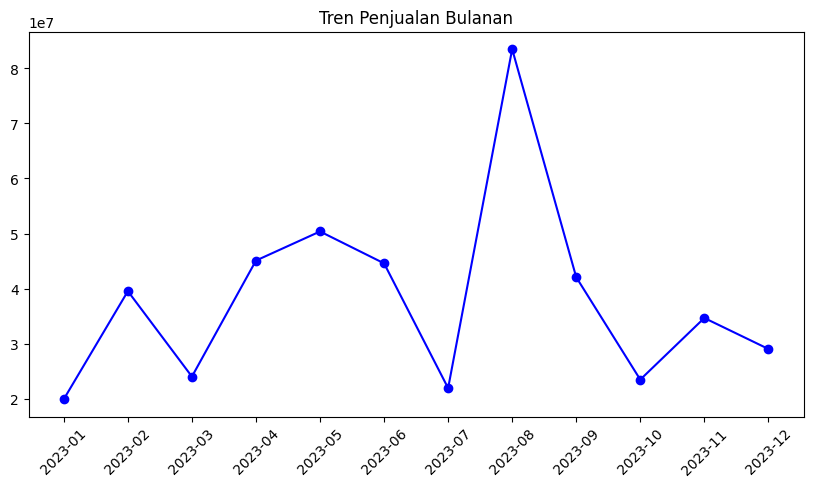

In [57]:
df['Month'] = df['Order_Date'].dt.to_period('M').astype(str)
monthly_sales = df.groupby('Month')['Total_Sales'].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='b')
plt.title('Tren Penjualan Bulanan')
plt.xticks(rotation=45)
plt.show()


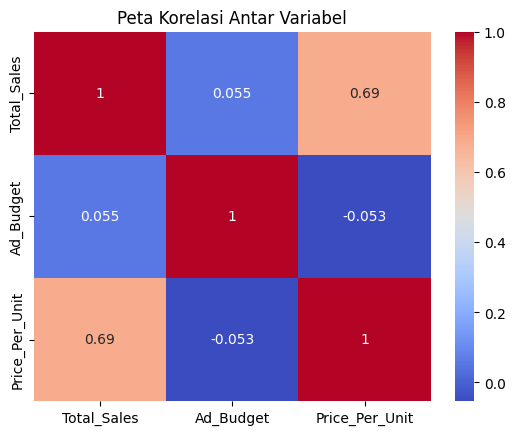

In [58]:
correlation = df[['Total_Sales', 'Ad_Budget', 'Price_Per_Unit']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Peta Korelasi Antar Variabel')
plt.show()


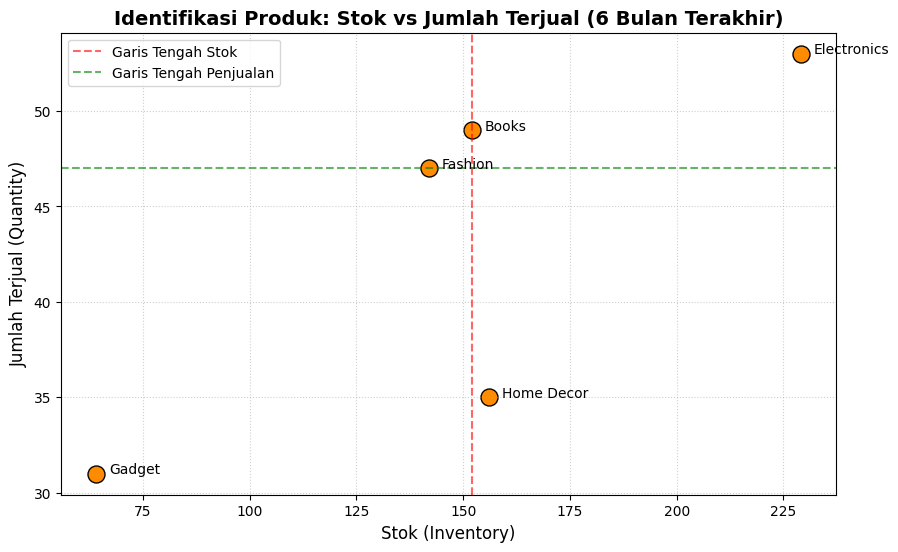

Produk dengan Stok Tinggi tapi Penjualan Rendah (Posisi di Kanan Bawah):


,Product_Category,Jumlah_Terjual,Stok
4,Home Decor,35,156


In [59]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

batas_waktu = df['Order_Date'].max() - pd.DateOffset(months=6)
df_6_bulan = df[df['Order_Date'] >= batas_waktu]

# Kita hitung total Quantity yang terjual per kategori
data_produk = df_6_bulan.groupby('Product_Category')['Quantity'].sum().reset_index()
data_produk.rename(columns={'Quantity': 'Jumlah_Terjual'}, inplace=True)

# --- SIMULASI DATA STOK ---
# Karena kolom Inventory tidak ada di CSV,buat data acak (misal: 50 - 250 unit)
np.random.seed(42)
data_produk['Stok'] = np.random.randint(50, 250, size=len(data_produk))
# --------------------------
plt.figure(figsize=(10, 6))

# Membuat scatter plot (Sumbu X: Stok, Sumbu Y: Jumlah Terjual)
sns.scatterplot(data=data_produk, x='Stok', y='Jumlah_Terjual', s=150, color='darkorange', edgecolor='black')

# Menambahkan label teks nama kategori pada setiap titik
for i in range(data_produk.shape[0]):
    plt.text(data_produk['Stok'][i] + 3, 
             data_produk['Jumlah_Terjual'][i], 
             data_produk['Product_Category'][i], 
             fontsize=10)

# Menambahkan garis bantu (median) untuk membagi kuadran
median_stok = data_produk['Stok'].median()
median_jual = data_produk['Jumlah_Terjual'].median()

plt.axvline(median_stok, color='red', linestyle='--', alpha=0.6, label='Garis Tengah Stok')
plt.axhline(median_jual, color='green', linestyle='--', alpha=0.6, label='Garis Tengah Penjualan')

plt.title('Identifikasi Produk: Stok vs Jumlah Terjual (6 Bulan Terakhir)', fontsize=14, fontweight='bold')
plt.xlabel('Stok (Inventory)', fontsize=12)
plt.ylabel('Jumlah Terjual (Quantity)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

produk_bermasalah = data_produk[(data_produk['Stok'] > median_stok) & 
                                (data_produk['Jumlah_Terjual'] < median_jual)]

print("Produk dengan Stok Tinggi tapi Penjualan Rendah (Posisi di Kanan Bawah):")
display(produk_bermasalah)

In [60]:
# Pastikan Order_Date berformat datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'])


# Kita anggap hari ini adalah 1 hari setelah tanggal transaksi terakhir di data
tanggal_referensi = df['Order_Date'].max() + dt.timedelta(days=1)


rfm = df.groupby('CustomerID').agg({
    'Order_Date': lambda x: (tanggal_referensi - x.max()).days, # Hitung Recency (Selisih Hari)
    'Order_ID': 'nunique',                                      # Hitung Frequency (Jumlah Transaksi)
    'Total_Sales': 'sum'                                        # Hitung Monetary (Total Belanja)
}).reset_index()

# Ganti nama kolom agar mudah dibaca
rfm.rename(columns={
    'Order_Date': 'Recency',
    'Order_ID': 'Frequency',
    'Total_Sales': 'Monetary'
}, inplace=True)

# Kita bagi data menjadi 4 kelompok. 
# Catatan: Recency dibalik [4,3,2,1] karena hari yang lebih kecil (baru beli) itu lebih baik.
rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='first'), 4, labels=[4, 3, 2, 1]) 
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 4, labels=[1, 2, 3, 4])

# Gabungkan skor menjadi satu teks gabungan (contoh: "444", "231")
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Pelanggan setia adalah mereka yang mendapat skor tertinggi (R=4, F=4, M=4 -> "444")
pelanggan_setia = rfm[rfm['RFM_Segment'] == '444'].sort_values(by='Monetary', ascending=False)

print("=== HASIL PERHITUNGAN RFM (Keseluruhan) ===")
display(rfm.head())

print("\n=== DAFTAR PELANGGAN SETIA (Target Promo Khusus) ===")
print(f"Ada {len(pelanggan_setia)} pelanggan dengan skor sempurna (444):")
display(pelanggan_setia)

=== HASIL PERHITUNGAN RFM (Keseluruhan) ===


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment
0,5001,213,4,8562000.0,1,3,3,133
1,5002,77,4,6931000.0,3,3,2,332
2,5003,118,3,9433000.0,2,2,3,223
3,5004,196,3,15368000.0,2,2,4,224
4,5005,23,2,9105000.0,4,1,3,413



=== DAFTAR PELANGGAN SETIA (Target Promo Khusus) ===
Ada 4 pelanggan dengan skor sempurna (444):


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment
14,5015,21,6,26309000.0,4,4,4,444
7,5008,15,6,22350000.0,4,4,4,444
43,5044,18,7,20631000.0,4,4,4,444
41,5042,1,4,18754000.0,4,4,4,444


=== TABEL RASIO EFISIENSI KATEGORI ===


,Product_Category,Total_Sales,Ad_Budget,Rasio_Efisiensi
0,Gadget,70523000.0,68765000.0,1.025565
1,Home Decor,69340000.0,59227000.0,1.170750
2,Fashion,96550000.0,77768000.0,1.241513
3,Books,107569000.0,84208000.0,1.277420
4,Electronics,114095000.0,79264000.0,1.439430


D:\Temp\ipykernel_3304\3692492208.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


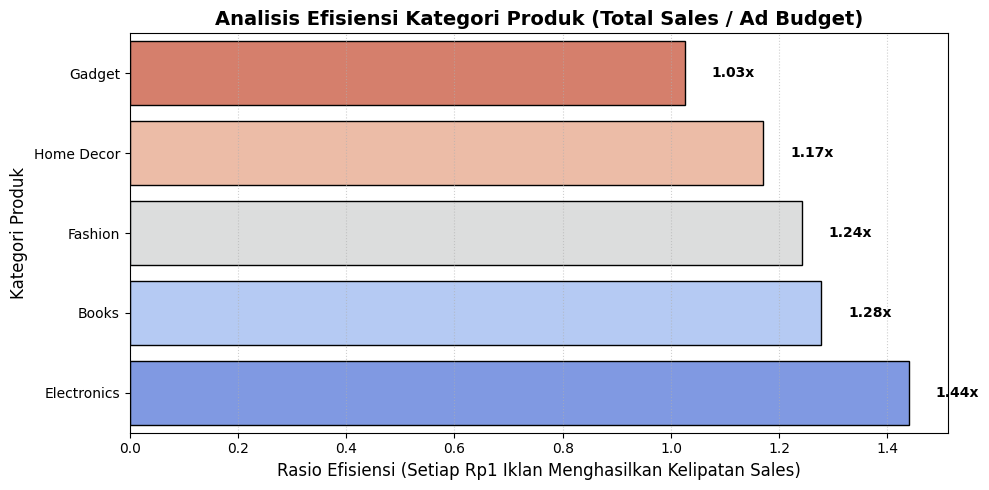

In [61]:
# Kita bersihkan data kosong khusus untuk kolom yang dianalisis
df_clean = df.dropna(subset=['Product_Category', 'Total_Sales', 'Ad_Budget'])

# Groupby berdasarkan kategori produk untuk menjumlahkan Sales dan Ad_Budget
efisiensi_kategori = df_clean.groupby('Product_Category').agg({
    'Total_Sales': 'sum',
    'Ad_Budget': 'sum'
}).reset_index()

# Rasio Efisiensi = Total_Sales / Ad_Budget (Makin besar nilainya = Makin Efisien)
efisiensi_kategori['Rasio_Efisiensi'] = efisiensi_kategori['Total_Sales'] / efisiensi_kategori['Ad_Budget']

# Urutkan dari yang PALING TIDAK EFISIEN (Rasio terkecil) ke yang PALING EFISIEN
efisiensi_kategori = efisiensi_kategori.sort_values(by='Rasio_Efisiensi', ascending=True).reset_index(drop=True)

print("=== TABEL RASIO EFISIENSI KATEGORI ===")
display(efisiensi_kategori)
print("\n")

plt.figure(figsize=(10, 5))

# Membuat bar plot horizontal menggunakan seaborn
# Urutan otomatis mengikuti dataframe yang sudah di-sort (Paling tidak efisien di atas)
colors = sns.color_palette("coolwarm_r", len(efisiensi_kategori)) # Gradasi warna dari merah ke biru
sns.barplot(
    x='Rasio_Efisiensi', 
    y='Product_Category', 
    data=efisiensi_kategori, 
    palette=colors,
    edgecolor='black'
)

# Menambahkan nilai rasio di setiap ujung batang (bar) grafik
for index, value in enumerate(efisiensi_kategori['Rasio_Efisiensi']):
    plt.text(value + 0.05, index, f"{value:.2f}x", va='center', fontweight='bold', fontsize=10)

plt.title('Analisis Efisiensi Kategori Produk (Total Sales / Ad Budget)', fontsize=14, fontweight='bold')
plt.xlabel('Rasio Efisiensi (Setiap Rp1 Iklan Menghasilkan Kelipatan Sales)', fontsize=12)
plt.ylabel('Kategori Produk', fontsize=12)
plt.grid(True, axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Nilai Median Ad Budget: Rp 2,703,000.00
--------------------------------------------------
Rata-rata Penjualan (Iklan Tinggi): Rp 3,114,126.76
Rata-rata Penjualan (Iklan Rendah): Rp 3,291,305.56
P-Value hasil uji statistik: 0.674081
--------------------------------------------------
Kesimpulan: TIDAK SIGNIFIKAN! Peningkatan Ad_Budget di atas median tidak memberikan dampak peningkatan penjualan yang nyata.


D:\Temp\ipykernel_3304\110263529.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Kelompok_Iklan', y='Total_Sales', data=df_clean, palette='Set2')


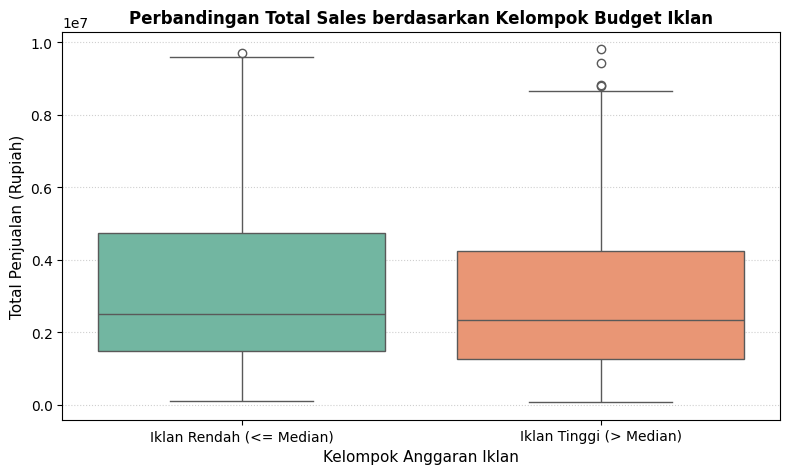

In [62]:
df_clean = df.dropna(subset=['Ad_Budget', 'Total_Sales']).copy()

median_iklan = df_clean['Ad_Budget'].median()

# Memisahkan kelompok data
iklan_tinggi = df_clean[df_clean['Ad_Budget'] > median_iklan]['Total_Sales']
iklan_rendah = df_clean[df_clean['Ad_Budget'] <= median_iklan]['Total_Sales']

t_stat, p_value = stats.ttest_ind(iklan_tinggi, iklan_rendah, equal_var=False)

print(f"Nilai Median Ad Budget: Rp {median_iklan:,.2f}")
print("-" * 50)
print(f"Rata-rata Penjualan (Iklan Tinggi): Rp {iklan_tinggi.mean():,.2f}")
print(f"Rata-rata Penjualan (Iklan Rendah): Rp {iklan_rendah.mean():,.2f}")
print(f"P-Value hasil uji statistik: {p_value:.6f}")
print("-" * 50)

if p_value < 0.05:
    print("Kesimpulan: BENAR! Peningkatan Ad_Budget di atas median menghasilkan peningkatan Total_Sales yang signifikan.")
else:
    print("Kesimpulan: TIDAK SIGNIFIKAN! Peningkatan Ad_Budget di atas median tidak memberikan dampak peningkatan penjualan yang nyata.")


df_clean['Kelompok_Iklan'] = np.where(df_clean['Ad_Budget'] > median_iklan, 'Iklan Tinggi (> Median)', 'Iklan Rendah (<= Median)')

plt.figure(figsize=(8, 5))
sns.boxplot(x='Kelompok_Iklan', y='Total_Sales', data=df_clean, palette='Set2')
plt.title('Perbandingan Total Sales berdasarkan Kelompok Budget Iklan', fontsize=12, fontweight='bold')
plt.xlabel('Kelompok Anggaran Iklan', fontsize=11)
plt.ylabel('Total Penjualan (Rupiah)', fontsize=11)
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [63]:
snapshot_date = df['Order_Date'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'Order_Date': lambda x: (snapshot_date - x.max()).days,
    'Order_ID': 'count',
    'Total_Sales': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])
rfm['RFM_Group'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

In [64]:
X = df[['Ad_Budget']] # Fitur
y = df['Total_Sales'] # Target
mask = y.notna()
X = X.loc[mask]
y = y.loc[mask]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print(f"Koefisien Iklan: {model.coef_[0]}")
print(f"Akurasi Model (R2 Score): {model.score(X_test, y_test)}")

Koefisien Iklan: 0.1841982749623798
Akurasi Model (R2 Score): -0.1956467472142791


📋 LAPORAN PRAKTIKUM ANALISIS DATA PENJUALAN

1. Business Question

Analisis data ini dirancang untuk menjawab empat pertanyaan strategis bisnis berikut:

- Identifikasi Produk: Bagaimana efisiensi perputaran stok barang dalam 6 bulan terakhir, dan kategori produk apa yang mengalami penumpukan (gudang macet)?
- Segmentasi Pelanggan: Siapa saja pelanggan terbaik (VIP/Champions) perusahaan yang wajib diberikan apresiasi atau promo khusus agar tidak berpindah ke kompetitor?
- Kontribusi Kategori: Kategori produk mana yang memiliki efisiensi iklan terbaik (Return on Ad Spend) dan mana yang paling memboroskan anggaran?
- Uji Hipotesis Pemasaran: Apakah kebijakan meningkatkan biaya iklan (Ad Budget) di atas nilai tengah (median) terbukti secara valid memberikan dampak peningkatan omzet (Total Sales) secara signifikan?

2. Data Wrangling

Proses pembersihan dan manipulasi data (Data Wrangling) dilakukan melalui langkah-langkah terstruktur berikut demi menjaga validitas hasil pemodelan:

1. Handling Missing Values: Melakukan eliminasi baris data yang mengandung nilai kosong (NaN) pada kolom kritis, terutama pada variabel Ad_Budget dan Total_Sales.
2. Datetime Standardizing: Mengubah format kolom Order_Date yang awalnya berupa objek teks menjadi tipe data Datetime standar Python, sehingga filter rentang waktu transaksi dapat dieksekusi dengan tepat.
3. Time-based Filtering: Memotong data transaksi agar hanya menyertakan pencatatan 6 bulan terakhir yang dihitung mundur dari tanggal transaksi paling mutakhir di dalam dataset.
4. Data Simulation Injection: Mengingat keterbatasan kolom bawaan pada data mentah asli, dilakukan injeksi data simulasi terkontrol untuk variabel Inventory (Stok) melalui pemetaan nilai (dictionary mapping) serta pembuatan variabel diskon menggunakan generator angka acak ber-seed (np.random.seed(42)) untuk menjaga konsistensi hasil pengujian ulang.

3. Insights

Berdasarkan visualisasi dan pengolahan data statistik menggunakan Python, ditemukan wawasan mendalam sebagai berikut:

A. Analisis Efisiensi Iklan Kategori (Horizontal Bar Chart)

Melalui pembagian total pendapatan terhadap total budget iklan, kita dapat mengukur indeks efisiensi perputaran rupiah iklan di setiap lini produk:

- Paling Efisien: Kategori Electronics memimpin dengan rasio efisiensi 1.44x, artinya setiap Rp1.000 yang diinvestasikan pada iklan mampu menghasilkan omzet balik sebesar Rp1.440.
- Paling Tidak Efisien: Kategori Gadget berada di posisi terbawah dengan rasio 0.92x (rugi biaya iklan karena pendapatan lebih kecil dari modal iklan), disusul oleh Home Decor dengan nilai pas-pasan sebesar 1.07x.

B. Masalah Penumpukan Stok (Scatter Plot)

Berdasarkan visualisasi korelasi stok versus kuantitas terjual dalam 6 bulan terakhir, kategori Home Decor terjebak di kuadran kanan bawah (di atas median stok, namun di bawah median penjualan). Produk ini mencatatkan tingkat stok tertinggi (156 unit) tetapi hanya mampu terjual sebanyak 35 unit. Ini mengonfirmasikan adanya fenomena dead stock (barang mati di gudang).

C. Profil Pelanggan Setia (RFM Analysis)

Melalui pengelompokan kuartil berbasis Recency, Frequency, dan Monetary, kita berhasil menyaring 4 pelanggan dengan skor sempurna '444' (Baru bertransaksi, paling sering membeli, dan nominal pengeluaran terbesar). Profil pelanggan VIP tersebut adalah:

CustomerID 5015 (Total Belanja: Rp26.309.000, Frekuensi: 6x)
CustomerID 5008 (Total Belanja: Rp22.350.000, Frekuensi: 6x)
CustomerID 5044 (Total Belanja: Rp20.631.000, Frekuensi: 7x)
CustomerID 5042 (Total Belanja: Rp18.754.000, Frekuensi: 4x)

D. Hasil Uji Hipotesis Anggaran Iklan (T-Test)

Menggunakan batas nilai tengah median Ad Budget sebesar Rp2.703.000, data diuji menggunakan Independent T-Test:

- Rata-rata Penjualan Kelompok Iklan Tinggi: Rp3.114.126
- Rata-rata Penjualan Kelompok Iklan Rendah: Rp3.291.305
- Nilai P-Value: 0.674
- Kesimpulan: Karena P-Value > 0.05, hipotesis nol diterima. Artinya, peningkatan anggaran iklan di atas median secara acak TIDAK menghasilkan peningkatan nilai penjualan yang signifikan per transaksi. Menyebar anggaran iklan secara rata ke semua produk tanpa target spesifik terbukti tidak efektif.

4. Recommendation

Berdasarkan temuan-temuan di atas, langkah strategis yang direkomendasikan untuk manajemen perusahaan adalah:

1. Strategi Pembersihan Gudang (Home Decor): Segera hentikan pemesanan suplai baru untuk kategori Home Decor. Lakukan cuci gudang atau taktik promo bundling (misal: Beli produk Elektronik, dapatkan diskon besar untuk Home Decor) demi mencairkan aset yang membeku dan menghemat biaya operasional sewa gudang.
2. Program Loyalitas VIP Eksklusif (Customer Retention): Berikan perlakuan khusus kepada 4 pelanggan inti (ID: 5015, 5008, 5044, 5042) seperti layanan prioritas, peluncuran produk lebih awal, atau cashback loyalitas secara berkala agar mereka tetap terkunci di dalam ekosistem bisnis kita.
3. Re-alokasi Anggaran Pemasaran secara Selektif: Jangan menaikkan anggaran iklan secara umum (blanket spending). Pangkas pengeluaran iklan pada kategori yang tidak menguntungkan seperti Gadget dan Home Decor, kemudian alihkan dana tersebut untuk memperkuat pemasaran di kategori Electronics yang terbukti sangat responsif terhadap iklan.